## Reddit users reaction to new Ferrari Luce release

This analysis examines Reddit users’ public reaction to **Ferrari Luce** following its full reveal on **25 May 2026**, focusing on overall sentiment, key discussion themes, and whether reactions differ across global or regional Reddit communities.

*The important caveat: Reddit does not reliably provide user country/location. So instead of saying “reaction by country”, we frame it as reaction across regional discussion contexts, approximated using country-specific subreddits, language, and subreddit audience.*

In [297]:
import pandas as pd
import numpy as np

from datetime import datetime, timezone
import time
import json
import re
import os
from os import getenv
from dotenv import load_dotenv

import praw
from praw.models import MoreComments

from langdetect import detect, DetectorFactory
from langdetect.lang_detect_exception import LangDetectException
# make language detection reproducible
DetectorFactory.seed = 42

import deepl

import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

from transformers import pipeline
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from tqdm.auto import tqdm
import torch

from pydantic import BaseModel, Field
from google import genai
from google.genai import types

from sklearn.metrics import classification_report

import matplotlib as plt

In [130]:
# Load the credentials stored in the .env file
load_dotenv()

True

In [41]:
# Create a read-only Reddit API connection
reddit = praw.Reddit(
    client_id=getenv("APP_ID"),         # Reddit app client ID
    client_secret=getenv("APP_SECRET"), # Reddit app secret
    user_agent=f"pda-2023 u/{getenv('REDDIT_USERNAME')}", # app-name u/username
)

# quick check that the connection object was created
reddit.read_only

True

In [42]:
# Test the Reddit API connection using a public subreddit
# if the API connection works, this should print the subreddit name and title
subreddit = reddit.subreddit("Ferrari")
print("Subreddit display name:", subreddit.display_name)
print("Subreddit title:", subreddit.title)

Subreddit display name: Ferrari
Subreddit title: "Aerodynamics are for people who can't build engines" - Enzo Ferrari


## Data collection plan

We collect both posts and comments, but use **comments as the main sentiment unit**. Posts are useful for context, but comments give better volume and variety.

In [43]:
# Search phrases related to the car
# exact phrase "Ferrari Luce" should be the most important one
search_queries = [
    '"Ferrari Luce"',
    'Ferrari Luce',
    '"new Ferrari" Luce',
    '"electric Ferrari" Luce',
    '"Ferrari EV" Luce'
]

Then we add regional/contextual ones **if they return data**, for example UK, Italy, Europe, India, Australia, UAE/Dubai, US car communities. 

But we'll need to validate them empirically rather than assume all will contain relevant posts.

### Important technical point

PRAW’s Reddit search supports only preset `time_filter` values such as "hour", "day", "week", "month", "year", and "all" rather than an arbitrary date range, so we should collect candidate posts and then filter locally using `created_utc` >= `release_timestamp`.

In [44]:
# main public reveal date for Ferrari Luce
release_date = datetime(2026, 5, 25, tzinfo=timezone.utc)

# convert to unix timestamp because Reddit stores dates as created_utc timestamps
release_timestamp = release_date.timestamp()

release_date, release_timestamp

(datetime.datetime(2026, 5, 25, 0, 0, tzinfo=datetime.timezone.utc),
 1779667200.0)

### Search Reddit broadly

We can start with `r/all`, then later add specific subreddits if needed.

In [45]:
# list to store collected post records
post_records = []

# keep track of seen post IDs to avoid duplicates across search queries
seen_submission_ids = set()

# search across `r/all` first
search_subreddit = reddit.subreddit("all")

# loop through each query
for query in search_queries:
    
    print(f"Searching for: {query}")
    
    # search Reddit posts
    # sort="new" helps with date-based collection
    # time_filter="year" keeps the search broad enough while still manageable
    for submission in search_subreddit.search(
        query=query,
        sort="new",
        time_filter="month",
        limit=None):
        
        # skip duplicate posts already found by another query
        if submission.id in seen_submission_ids:
            continue
        
        # keep only posts created on or after 25 May 2026
        if submission.created_utc < release_timestamp:
            continue
        
        # add this post ID to seen set
        seen_submission_ids.add(submission.id)
        
        # store useful metadata
        post_records.append({
            "submission_id": submission.id,
            "subreddit": str(submission.subreddit),
            "title": submission.title,
            "selftext": submission.selftext,
            "created_utc": submission.created_utc,
            "created_datetime": datetime.fromtimestamp(
                submission.created_utc,
                tz=timezone.utc),
            "score": submission.score,
            "upvote_ratio": submission.upvote_ratio,
            "num_comments": submission.num_comments,
            "url": submission.url,
            "permalink": "https://www.reddit.com" + submission.permalink,
            "query_used": query
        })
    
    # gentle pause to avoid hammering the API
    time.sleep(1)

Searching for: "Ferrari Luce"
Searching for: Ferrari Luce
Searching for: "new Ferrari" Luce
Searching for: "electric Ferrari" Luce
Searching for: "Ferrari EV" Luce


In [46]:
# create dataframe from collected records
posts_df = pd.DataFrame(post_records)

# inspect shape
posts_df.shape

(415, 12)

In [48]:
# check how many posts were collected per subreddit
posts_df["subreddit"].value_counts()

subreddit
Ferrari              70
carscirclejerk       17
AiCarArt             16
CarDesign            13
ItalyMotori          12
                     ..
u_JLAFORUMSDOTCOM     1
NemoMoney             1
tech_flames           1
phcars                1
EVStocks              1
Name: count, Length: 202, dtype: int64

In [51]:
# check date range of collected posts
posts_df["created_datetime"].min(), posts_df["created_datetime"].max()

(Timestamp('2026-05-25 20:16:50+0000', tz='UTC'),
 Timestamp('2026-06-11 10:46:01+0000', tz='UTC'))

In [50]:
# save raw post-level dataset
posts_df.to_csv("ferrari_luce_reddit_posts_raw.csv", index=False)

In [52]:
posts_df.shape

(415, 12)

In [53]:
# inspect the posts that produced the most discussion
posts_df.sort_values("num_comments", ascending=False)[
    [
        "created_datetime",
        "subreddit",
        "title",
        "score",
        "num_comments",
        "query_used",
        "permalink"
    ]
].head(5)

,created_datetime,subreddit,title,score,num_comments,query_used,permalink
20,2026-06-09 17:57:06+00:00,Ferrari,Ferrari Luce Commercial Filming in SF,1493,664,"""Ferrari Luce""",https://www.reddit.com/r/Ferrari/comments/1u1c...
402,2026-05-25 20:16:50+00:00,Ferrari,Official press photo of the new all electric F...,784,635,"""electric Ferrari"" Luce",https://www.reddit.com/r/Ferrari/comments/1tnk...
345,2026-05-26 20:41:04+00:00,formula1,Hamilton and Leclerc revealing the new Ferrari...,4034,441,"""new Ferrari"" Luce",https://www.reddit.com/r/formula1/comments/1to...
365,2026-05-26 04:31:10+00:00,ChatGPT,The 'Ferrari Elettrica' - Today I was disappoi...,2181,385,"""new Ferrari"" Luce",https://www.reddit.com/r/ChatGPT/comments/1tnw...
14,2026-06-09 22:42:41+00:00,spotted,[Ferrari Luce] spotted in downtown SF for prom...,985,325,"""Ferrari Luce""",https://www.reddit.com/r/spotted/comments/1u1k...


### Source-type classification

In [54]:
# main Ferrari / car / EV discussion communities
core_auto_subreddits = ["Ferrari", "cars", "supercars", "CarDesign", "electricvehicles", "electriccars", 
                        "automotive", "askcarguys", "Cartalk", "StupidCarQuestions", "TrueCarEnthusiasts", 
                        "whatcarshouldIbuy"]

# auto-brand or model-specific communities where Ferrari Luce is discussed comparatively
cross_brand_auto_subreddits = ["LUCID", "Toyota", "Audi", "Porsche", "lamborghini", "BMWi3", "leaf", "TeslaLounge", 
                               "Taycan", "mercedes_benz", "Honda", "Charger", "chargerdaytona"]

# Ferrari-related motorsport/F1 communities
# These can be useful because Ferrari is both a car brand and F1 brand
motorsport_subreddits = ["formula1", "Formula1_world", "Formula1Italia"]

# design-focused communities
design_subreddits = ["Design", "IndustrialDesign", "product_design", "branding", "cassettefuturism", "LoveFrom"]

# regional car/EV communities
regional_auto_subreddits = [
    # UK
    "CarTalkUK", "ElectricVehiclesUK", "ukcarwow", "autoexpressuk", "pistonheads", "TheIntercooler",
    # Italy
    "ItalyMotori", "Motorionline", "Auto_Passion",
    # Germany / German-language
    "automobil", "CarwowDE",
    # India
    "CarsIndia", "Autoexpoindia", "cargeeksindia", "indocartalk",
    # South Africa
    "CarTalkZA",
    # UAE / Dubai
    "DubaiPetrolHeads",
    # Hungary
    "CartalkHungary",
    # Brazil / Portugal / Portuguese-language
    "carros", "Carroseletricos", "CarrosEletricosPT",
    # Australia / New Zealand
    "CarsAustralia", "EVAustralia", "KiwiEV",
    # Philippines / Malaysia / Pakistan
    "Gulong", "CarsPH", "phcars", "kereta", "PakistanAutoHub",
    # Serbia / Spain / France / Kenya / Turkey
    "srbija_automobili", "CarCulture_ES", "CarwowES", "Vilebrequin", "Kenya_got_rides", "HotWheelsTr"]

# auto media / news repost sources
auto_media_or_news_subreddits = ["AutoNewspaper", "BBCauto", "NBCauto", "MotoringNews", "MotorBuzz", "carwow", 
                                 "dougdemuro", "regularcarreviews", "JasonCammisa", "SpikesCarRadio", 
                                 "TheVergecast", "T3dotcom"]

# meme / satire communities
satire_or_meme_subreddits = ["carscirclejerk", "formuladank", "memes", "meme", "AutoHumor", "eestimeemid", 
                             "CirclejerkSopranos", "TheSarcasticSociety", "SipsTea", "AccidentalComedy"]

# AI / speculative / alternative design communities
ai_or_speculative_subreddits = ["AiCarArt", "whatifcars", "ChatGPT", "OpenAI", "generativeAI"]


def classify_source_type(subreddit):
    if subreddit in core_auto_subreddits:
        return "core_auto"
    elif subreddit in cross_brand_auto_subreddits:
        return "cross_brand_auto"
    elif subreddit in motorsport_subreddits:
        return "motorsport_ferrari_context"
    elif subreddit in design_subreddits:
        return "design_discussion"
    elif subreddit in regional_auto_subreddits:
        return "regional_auto"
    elif subreddit in auto_media_or_news_subreddits:
        return "auto_media_or_news"
    elif subreddit in satire_or_meme_subreddits:
        return "satire_meme"
    elif subreddit in ai_or_speculative_subreddits:
        return "ai_or_speculative"
    else:
        return "other"

In [55]:
posts_df["source_type"] = posts_df["subreddit"].apply(classify_source_type)
posts_df["source_type"].value_counts()

source_type
other                         130
core_auto                     112
regional_auto                  70
satire_meme                    26
auto_media_or_news             25
ai_or_speculative              25
cross_brand_auto               13
design_discussion               9
motorsport_ferrari_context      5
Name: count, dtype: int64

#### Regional proxy

This is still a subreddit-context proxy, not confirmed commenter location.

In [56]:
region_map = {
    # UK
    "CarTalkUK": "UK",
    "ElectricVehiclesUK": "UK",
    "ukcarwow": "UK",
    "autoexpressuk": "UK",
    "pistonheads": "UK",
    "TheIntercooler": "UK",

    # Italy
    "ItalyMotori": "Italy",
    "Motorionline": "Italy",
    "Formula1Italia": "Italy",
    "Economia_Italiana": "Italy",
    "ItaliaBox": "Italy",
    "TeenagersITA": "Italy",

    # Germany / German-language
    "automobil": "Germany / German-language",
    "CarwowDE": "Germany / German-language",
    "SmartDroidDE": "Germany / German-language",
    "wasletztepreis": "Germany / German-language",
    "Weltnachrichten": "Germany / German-language",

    # India
    "CarsIndia": "India",
    "Autoexpoindia": "India",
    "cargeeksindia": "India",
    "indocartalk": "India",
    "Hotwheelsindia": "India",
    "BusinessTodayNews": "India",

    # South Africa
    "CarTalkZA": "South Africa",

    # UAE / Dubai
    "DubaiPetrolHeads": "UAE / Dubai",

    # Hungary
    "CartalkHungary": "Hungary",

    # Brazil / Portugal / Portuguese-language
    "carros": "Brazil / Portuguese-language",
    "Carroseletricos": "Brazil / Portuguese-language",
    "CarrosEletricosPT": "Portugal / Portuguese-language",
    "reclamacoesfuteis": "Portuguese-language",

    # Australia / New Zealand
    "CarsAustralia": "Australia",
    "EVAustralia": "Australia",
    "KiwiEV": "New Zealand",

    # Philippines / Malaysia / Pakistan
    "Gulong": "Philippines",
    "CarsPH": "Philippines",
    "phcars": "Philippines",
    "Tech_Philippines": "Philippines",
    "kereta": "Malaysia",
    "PakistanAutoHub": "Pakistan",

    # France / French-language
    "Vilebrequin": "France / French-language",
    "Frandroid": "France / French-language",
    "opinionnonpopulaire": "France / French-language",
    "rienabranler": "France / French-language",

    # Other regional contexts
    "srbija_automobili": "Serbia",
    "Roumanie": "Romania",
    "CarCulture_ES": "Spain / Spanish-language",
    "CarwowES": "Spain / Spanish-language",
    "Kenya_got_rides": "Kenya",
    "ottawa": "Canada / Ottawa",
    "HotWheelsTr": "Turkey",

    # global or non-country-specific
    "Ferrari": "Global / brand-specific",
    "cars": "Global",
    "supercars": "Global",
    "electricvehicles": "Global",
    "electriccars": "Global",
    "CarDesign": "Global",
    "Design": "Global",
    "IndustrialDesign": "Global",
    "formula1": "Global / F1",
    "LUCID": "Global / brand-specific",
    "Toyota": "Global / brand-specific",
    "Audi": "Global / brand-specific",
    "Porsche": "Global / brand-specific",
    "lamborghini": "Global / brand-specific",
    "BMWi3": "Global / brand-specific"
}

posts_df["region_proxy"] = posts_df["subreddit"].map(region_map).fillna("Unclear / other")

#### Relevance filter

In [57]:
# combine searchable fields
posts_df["combined_text"] = (
    posts_df["title"].fillna("") + " " +
    posts_df["selftext"].fillna("") + " " +
    posts_df["url"].fillna("") + " " +
    posts_df["query_used"].fillna("")
)

posts_df["combined_text_lower"] = posts_df["combined_text"].str.lower()

# broad relevance filter
posts_df["is_luce_related"] = (
    posts_df["combined_text_lower"].str.contains("luce", na=False)
    |
    posts_df["combined_text_lower"].str.contains("ferrari elettrica", na=False)
    |
    posts_df["combined_text_lower"].str.contains("electric ferrari", na=False)
    |
    posts_df["combined_text_lower"].str.contains("ferrari ev", na=False)
)

In [58]:
# check high-comment posts that fail the filter
posts_df.loc[
    ~posts_df["is_luce_related"]
].sort_values("num_comments", ascending=False)[
    ["subreddit", "source_type", "title", "num_comments", "query_used", "permalink"]
].head(30)

,subreddit,source_type,title,num_comments,query_used,permalink


## Main dataset for comment collection

In [59]:
# Define source types to exclude from the main analysis
# We exclude satire/meme and AI/speculative communities because their language may distort sentiment:
# - satire_meme: sarcasm, jokes, exaggeration
# - ai_or_speculative: may discuss AI-generated or hypothetical designs rather than the actual Ferrari Luce
excluded_source_types = [
    "satire_meme",
    "ai_or_speculative"
]

# Create the main post dataset for comment collection
# Keep:
# - Luce-related posts
# - posts with at least one comment
# - posts that are not satire/meme or AI/speculative
main_posts_df = posts_df[
    (posts_df["is_luce_related"])
    &
    (posts_df["num_comments"] > 0)
    &
    (~posts_df["source_type"].isin(excluded_source_types))
].copy()

# submissions to exclude from the whole analysis (manually found some irrelevant posts)
excluded_submission_ids = ["1txg5qo", "1tvy0zq", "1tvmvro", "1tv8o0t", "1tuw4l4", "1tu7y2w", "1tt2dgu", "1tt1zko",
                           "1tss5vu", "1tsankt", "1trpkze", "1tr6qus", "1tr5or9", "1tr0x4j", "1tqywtb", "1tqou1l",
                           "1tq3lub", "1tq1ja9", "1tpzfsb", "1tpupvn", "1tpu9tr", "1twr606", "1tuvopu", "1ttg783",
                           "1tser5r", "1tolq41", "1to1hod", "1tnyo9s", "1txyr46", "1ty123c", "1u02quh", "1u1f7bi",
                           "1u1jw2y", "1u240jc", "1u27aec", "1u2omzz", "1u2qudp", "1u2vk5j"]

# filter posts
posts_sentiment_df = main_posts_df[~main_posts_df["submission_id"].isin(excluded_submission_ids)].copy()
posts_sentiment_df.shape

(242, 17)

In [60]:
# Summarise retained posts by source type
main_source_summary = (posts_sentiment_df.groupby("source_type").agg(
        post_count=("submission_id", "count"),
        total_comments=("num_comments", "sum"),
        median_comments=("num_comments", "median"),
        max_comments=("num_comments", "max")
    ).sort_values("total_comments", ascending=False))

main_source_summary

,post_count,total_comments,median_comments,max_comments
source_type,,,,
core_auto,97,5765,19.0,664
regional_auto,57,3257,32.0,317
other,62,2338,9.5,325
design_discussion,8,539,31.0,249
cross_brand_auto,11,445,27.0,133
motorsport_ferrari_context,1,441,441.0,441
auto_media_or_news,6,348,44.0,182


In [62]:
# Save the filtered post-level dataset used for main comment collection
main_posts_df.to_csv("ferrari_luce_reddit_posts_main.csv", index=False)

### Collect comments from filtered posts

In [63]:
# List to store comment-level records
comment_records = []

# Convert main post IDs to a list
submission_ids = posts_sentiment_df["submission_id"].tolist()

# Loop through selected posts
for i, submission_id in enumerate(submission_ids, start=1):
    
    print(f"Collecting comments from post {i}/{len(submission_ids)}: {submission_id}")
    
    # Get submission object from Reddit API
    submission = reddit.submission(id=submission_id)
    
    # Replace MoreComments objects so we can access the full comment tree
    # limit=None attempts to load all available comments
    submission.comments.replace_more(limit=None)
    
    # Get matching post metadata from main_posts_df
    post_row = posts_sentiment_df.loc[posts_sentiment_df["submission_id"] == submission_id].iloc[0]
    
    # Loop through all comments in the flattened comment tree
    for comment in submission.comments.list():
        
        # Skip non-comment placeholder objects just in case
        if isinstance(comment, MoreComments):
            continue
        
        # Keep only comments created on or after the reveal date
        if comment.created_utc < release_timestamp:
            continue
        
        # Store useful comment metadata
        comment_records.append({
            "comment_id": comment.id,
            "submission_id": submission_id,
            "subreddit": str(submission.subreddit),
            "source_type": post_row["source_type"],
            "region_proxy": post_row.get("region_proxy", None),
            "post_title": submission.title,
            "post_created_utc": submission.created_utc,
            "post_created_datetime": datetime.fromtimestamp(
                submission.created_utc,
                tz=timezone.utc
            ),
            "comment_created_utc": comment.created_utc,
            "comment_created_datetime": datetime.fromtimestamp(
                comment.created_utc,
                tz=timezone.utc
            ),
            "comment_body": comment.body,
            "comment_score": comment.score,
            "comment_parent_id": comment.parent_id,
            "comment_permalink": "https://www.reddit.com" + comment.permalink,
            "post_permalink": "https://www.reddit.com" + submission.permalink
        })
    
    # Gentle pause
    time.sleep(0.5)

In [64]:
# Comments collected on 11 Jun 2026, 19:30 (Dublin time)

# Convert to comments DataFrame
comments_df = pd.DataFrame(comment_records)
comments_df.shape

(12982, 15)

### Basic comment cleaning

In [65]:
# Make a copy for cleaning
comments_clean_df = comments_df.copy()

# Remove missing comments
comments_clean_df = comments_clean_df[comments_clean_df["comment_body"].notna()].copy()

# Remove deleted and removed comments
comments_clean_df = comments_clean_df[~comments_clean_df["comment_body"].isin(["[deleted]", "[removed]"])].copy()

# Remove AutoModerator comments if present
comments_clean_df = comments_clean_df[comments_clean_df["comment_body"].str.lower() != "automoderator"].copy()

# Create word count column
comments_clean_df["word_count"] = (comments_clean_df["comment_body"].str.split().str.len())

# Keep comments with at least 5 words
comments_clean_df = comments_clean_df[comments_clean_df["word_count"] >= 5].copy()

# Remove duplicate comments by exact text
comments_clean_df = comments_clean_df.drop_duplicates(subset=["comment_body"]).copy()

# Check final shape
comments_clean_df.shape

(10960, 16)

In [66]:
# Check cleaned comment distribution
comments_clean_df["source_type"].value_counts()

source_type
core_auto                     4811
regional_auto                 2727
other                         1869
design_discussion              483
motorsport_ferrari_context     383
cross_brand_auto               381
auto_media_or_news             306
Name: count, dtype: int64

In [68]:
# Save raw collected comments
comments_df.to_csv("ferrari_luce_reddit_comments_raw.csv", index=False)

# Save cleaned comments for sentiment analysis
comments_clean_df.to_csv("ferrari_luce_reddit_comments_clean.csv", index=False)

### Prepare the posts + comments dataset

In [69]:
# create post-level text
posts_items_df = posts_sentiment_df.copy()

posts_items_df["text"] = (
    posts_items_df["title"].fillna("") + " " +
    posts_items_df["selftext"].fillna("")
).str.strip()

posts_items_df["item_type"] = "post"
posts_items_df["item_id"] = posts_items_df["submission_id"]
posts_items_df["post_title"] = posts_items_df["title"]
posts_items_df["item_score"] = posts_items_df["score"]
posts_items_df["item_permalink"] = posts_items_df["permalink"]

posts_items_df = posts_items_df[["item_id", "submission_id", "item_type", "subreddit", "source_type", "region_proxy", "post_title", 
                                 "text", "item_score", "created_datetime", "item_permalink"]].copy()

In [70]:
# create comment-level text
comments_items_df = comments_clean_df.copy()

comments_items_df["text"] = comments_items_df["comment_body"]
comments_items_df["item_type"] = "comment"
comments_items_df["item_id"] = comments_items_df["comment_id"]
comments_items_df["item_score"] = comments_items_df["comment_score"]
comments_items_df["created_datetime"] = comments_items_df["comment_created_datetime"]
comments_items_df["item_permalink"] = comments_items_df["comment_permalink"]

comments_items_df = comments_items_df[["item_id", "submission_id", "item_type", "subreddit", "source_type", "region_proxy", "post_title", 
                                       "text", "item_score", "created_datetime", "item_permalink"]].copy()

In [71]:
# combine posts and comments into one analysis dataset
reddit_items_df = pd.concat([posts_items_df, comments_items_df], ignore_index=True)

# remove empty text
reddit_items_df = reddit_items_df[
    reddit_items_df["text"].notna() & 
    reddit_items_df["text"].str.strip().ne("")
].copy()

reddit_items_df.shape

(11202, 11)

In [72]:
reddit_items_df["item_type"].value_counts()

item_type
comment    10960
post         242
Name: count, dtype: int64

In [73]:
reddit_items_df.to_csv("ferrari_luce_reddit_posts_and_comments_clean.csv", index=False)

## Translate non-English posts and comments into English

In [75]:
def detect_language(text):
    """
    Detect the language of a string.
    
    Returns:
    - ISO language code, e.g. 'en', 'it', 'pt', 'fr'
    - 'unknown' if language detection fails
    """
    
    try:
        return detect(text)
    
    except LangDetectException:
        return "unknown"

In [76]:
reddit_items_df["language"] = reddit_items_df["text"].apply(detect_language)

In [78]:
# check language distribution
reddit_items_df["language"].value_counts().head(20)

language
en    9319
it     751
pt     311
de     182
hu     167
fr     113
et      62
af      54
es      43
ro      35
id      27
no      23
tl      21
ca      18
nl      18
da      12
tr      10
hr      10
so       8
cy       5
Name: count, dtype: int64

In [ ]:
auth_key = os.getenv("DEEPL_API_KEY")
translator = deepl.Translator(auth_key)

In [148]:
# Fetch usage details
usage = translator.get_usage()

if usage.any_limit_reached:
    print("⚠️ Warning: You have hit your DeepL API limit!")

if usage.character:
    count = usage.character.count
    limit = usage.character.limit
    remaining = limit - count
    
    print(f"Characters used so far: {count:,}")
    print(f"Your plan character limit: {limit:,}")
    print(f"Characters remaining: {remaining:,}")
    print(f"Usage percentage: {(count / limit) * 100:.2f}%")
else:
    print("Character usage tracking is not applicable to this account type.")

Characters used so far: 323,389
Your plan character limit: 1,000,000
Characters remaining: 676,611
Usage percentage: 32.34%


In [137]:
# to NOT to translate "Luce" itself (e.g. from italian into "light")
PROTECTED_TERMS = {"__FERRARI_LUCE__": "Luce"}

In [138]:
def protect_terms(text):
    """
    Replace Ferrari-specific terms with placeholders before translation.
    """
    text = str(text)
    text = re.sub(
        r"\bluce\b",
        "__FERRARI_LUCE__",
        text,
        flags=re.IGNORECASE
    )
    return text

In [139]:
def restore_terms(text):
    """
    Restore placeholders after translation.
    """
    text = str(text)
    for placeholder, original_term in PROTECTED_TERMS.items():
        text = text.replace(placeholder, original_term)

    return text

In [141]:
def translate_to_english(text, source_language):
    """
    Translate text into English using NLLB.

    Parameters:
        text : original text
        source_language : ISO language code (e.g. 'it', 'fr', 'de')
    Returns: English translation (str)
    """
    text = str(text)
    if source_language == "en":    # keep English unchanged
        return text
    protected_text = protect_terms(text)    # protect Ferrari model name

    try:
        result = translator.translate_text(protected_text, target_lang="EN-US")
        # restore Ferrari model names
        return restore_terms(result.text)    
    except Exception as e:
        print(f"Translation failed: {e}")
        return text

In [91]:
# Test before running on everything
sample_non_english = reddit_items_df[reddit_items_df["language"] != "en"].sample(10, random_state=42)

sample_non_english[["language", "text"]]

,language,text
6752,it,Ma infatti non ho compreso tanto il discorso s...
5606,fr,Ils ont bien pompé tesla quand même (en plus d...
3845,it,"Sì ma stai parlando di una 911, un modello che..."
3623,hu,"Lehet, hogy csak azért mert elvagyunk szokva t..."
3577,hu,Pont valamelyik nap voltak feltéve azok a régi...
2672,da,More like a Nissan leaf\n\nhttps://preview.red...
977,it,È come film di orrore
6395,de,Sehe ich nicht so. 10C Entladerate ist gar kei...
3055,pt,"Dizer que é feia é sobre opinião, mas tem amer..."
9485,ca,Una Ferrari Tartan Luce Prancer\n\nhttps://pre...


In [144]:
for _, row in sample_non_english.iterrows():

    translated = translate_to_english(
        row["text"],
        row["language"]
    )

    print("=" * 80)
    print(row["language"])
    print("ORIGINAL:")
    print(row["text"])
    print()
    print("TRANSLATED:")
    print(translated)

it
ORIGINAL:
Ma infatti non ho compreso tanto il discorso sull’aspetto finanziario. 

Ha fatto il 10% in vista dell’annuncio e il -7% dopo l’annuncio. 

Non sono Warren Buffet ma solo un piccolo investitore e l’ho vista con accezione positiva. Come dici tu, la gente ha incassato quel 10% vendendo subito dopo l’annuncio. Tipico. E il prezzo si è assestato nel canale precedente. Quindi tutto come prima e addirittura dopo qualche giorno è balzato oltre i massimi di trend. 

È il mercato reale che ci dirà se sta macchina piacerà o meno. 

La borsa ha andamenti suoi, specialmente a ridosso e in risposta agli eventi. E soprattutto chi investe, di comprare una Ferrari generalmente se ne frega altamente perché quei 500k messi nel posto giusto fruttano più erezioni di un’accelerazione scattante…

TRANSLATED:
Actually, I didn’t really understand the financial part of it. 

It went up 10% ahead of the announcement and down 7% after the announcement. 

I’m no Warren Buffett—just a small investor—a

In [147]:
# Apply on the full data set
tqdm.pandas()

reddit_items_df["translated_text"] = reddit_items_df.progress_apply(
    lambda row: translate_to_english(
        row["text"],
        row["language"]
    ),
    axis=1
)

  0%|          | 0/11202 [00:00<?, ?it/s]

In [151]:
# reddit_items_df[["text", "translated_text"]]
reddit_items_df[reddit_items_df["language"] != "en"][["text", "translated_text"]].sample(10)

,text,translated_text
5239,Better concept\n\n^(Chose: fiat multipla),Better concept\n\n^(Chose: fiat multipla)
5122,Ez egy elektromos limuzin. Mièrt keres mindenk...,It's an electric limousine. Why is everyone lo...
5365,comportarsi come se il cicli di RnD cinesi non...,Acting as if Chinese R&D cycles had no oversig...
4877,I like it better as a Prius,I like it better as a Prius
956,È ancora più brutta che nei render,It looks even worse than in the renderings
6767,Col cazzo che metto soldi in space X :D\n\n(Ma...,No way am I putting money into SpaceX :D\n\n(M...
3510,"Va beh, ma pure se trump scorreggia aumenta o ...","Okay, but even if Trump farts, something goes ..."
2496,"Quindi se ti fai la domanda ""perché non lavoro...","So if you ask yourself, ""Why don't I work at F..."
184,Ho avuto un'illuminazione sulla Luce Si tratta...,I had a revelation about the Luce. It’s a bril...
4350,Cosa ci sarebbe oltre la copertina? Prestazion...,What lies beneath the surface? Average perform...


In [156]:
reddit_items_df.to_csv("ferrari_luce_reddit_posts_and_comments_clean_translated.csv", index=False)

## Apply VADER as a baseline

In [161]:
# create a separate dataframe for VADER sentiment analysis
vader_df = reddit_items_df.copy()

# make sure comment text is stored as string
vader_df["translated_text"] = vader_df["translated_text"].astype(str)

# quick check
vader_df.shape

(11202, 13)

In [162]:
# initialise VADER sentiment analyser
analyzer = SentimentIntensityAnalyzer()

In [163]:
def get_vader_scores(text):
    """
    Apply VADER sentiment analysis to one text string.
    
    VADER returns four values:
    - neg: proportion of negative sentiment
    - neu: proportion of neutral sentiment
    - pos: proportion of positive sentiment
    - compound: overall sentiment score from -1 to +1
    """
    
    return analyzer.polarity_scores(text)

In [164]:
# apply VADER to each translated text
vader_scores = vader_df["translated_text"].apply(get_vader_scores)

# split dictionary output into separate dataframe columns
vader_scores_df = pd.DataFrame(vader_scores.tolist())

# add VADER scores back to main dataframe
vader_df = pd.concat([vader_df.reset_index(drop=True), vader_scores_df], axis=1)

# preview results
vader_df[["translated_text", "neg", "neu", "pos", "compound"]].sample(5)

,translated_text,neg,neu,pos,compound
5164,Thank you!🙏 I won't have any more sleepless n...,0.000,0.715,0.285,0.4199
3537,For a while they have been pretty gaudy and os...,0.000,0.656,0.344,0.7424
1501,"The more i look at it, the worse it gets",0.279,0.721,0.000,-0.4767
6517,I actually commend their attempt. When battery...,0.014,0.928,0.058,0.6597
8672,"I don't care for Ferrari, I'm just glad Sapphi...",0.072,0.767,0.162,0.5060


In [166]:
# Standard VADER thresholds
def label_vader_sentiment(compound_score):
    """
    Convert VADER compound score into sentiment label.
    
    Standard VADER thresholds:
    - positive: compound >= 0.05
    - negative: compound <= -0.05
    - neutral: between -0.05 and 0.05
    """
    
    if compound_score >= 0.05:
        return "positive"
    elif compound_score <= -0.05:
        return "negative"
    else:
        return "neutral"

In [167]:
# create sentiment label
vader_df["sentiment_label"] = vader_df["compound"].apply(label_vader_sentiment)

# check label counts
vader_df["sentiment_label"].value_counts()

sentiment_label
positive    5548
negative    3185
neutral     2469
Name: count, dtype: int64

In [168]:
# rename the VADER score columns so they are clear before adding other methods
vader_df = vader_df.rename(columns={
    "neg": "vader_neg",
    "neu": "vader_neu",
    "pos": "vader_pos",
    "compound": "vader_compound"
})

### Overall VADER sentiment summary

In [169]:
# count sentiment labels
sentiment_counts = vader_df["sentiment_label"].value_counts()

# convert counts to percentages
sentiment_percentages = (
    vader_df["sentiment_label"]
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
)

# combine counts and percentages into one table
overall_sentiment_summary = pd.DataFrame({
    "count": sentiment_counts,
    "percentage": sentiment_percentages
})

overall_sentiment_summary

,count,percentage
sentiment_label,,
positive,5548,49.5
negative,3185,28.4
neutral,2469,22.0


In [173]:
# save comment-level dataset with VADER scores
vader_df.to_csv("ferrari_luce_reddit_sentiments_vader.csv", index=False)

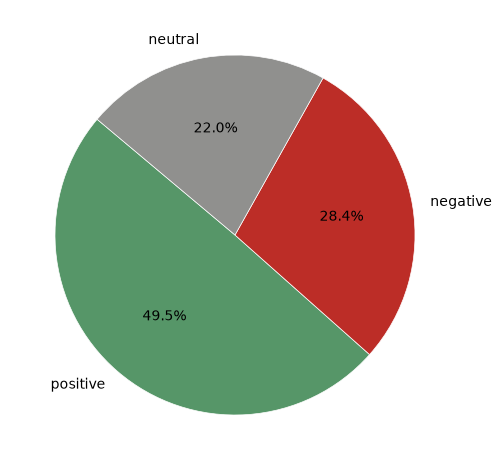

In [306]:
import matplotlib.pyplot as plt

color_map = {
    "negative": "#BC2D27",
    "neutral": "#90908E",
    "positive": "#569668"
}

# Ensure the colors match the row order of  sentiment summary
colors = [color_map[sentiment_label] for sentiment_label in overall_sentiment_summary.index]

# Plot the pie chart
fig, ax = plt.subplots()
ax.pie(
    overall_sentiment_summary["percentage"],
    labels=overall_sentiment_summary.index,
    colors=colors,
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 0.5}
)

plt.tight_layout()
plt.savefig("vader_sentiment_pie_chart.svg", format='svg')

## Twitter-roBERTa-base for Sentiment Analysis - UPDATED (2022)

https://huggingface.co/cardiffnlp/twitter-roberta-base-sentiment-latest

RoBERTa-base model trained on ~124M tweets from January 2018 to December 2021, and finetuned for sentiment analysis with the TweetEval benchmark. This model is **suitable for English**.

Labels: 0 -> Negative; 1 -> Neutral; 2 -> Positive

In [4]:
# load social-media sentiment model
roberta_sentiment = pipeline(
    task="sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment-latest",
    tokenizer="cardiffnlp/twitter-roberta-base-sentiment-latest",
    truncation=True
)

config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/501M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.weight | UNEXPECTED |  | 
roberta.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

In [174]:
test_result = roberta_sentiment("I love the design of the new Ferrari Luce.")
test_result

[{'label': 'positive', 'score': 0.9851456880569458}]

In [175]:
roberta_sentiment("The new Ferrari Luce looks terrible.")

[{'label': 'negative', 'score': 0.9341214895248413}]

In [176]:
def run_roberta_sentiment(text_series, batch_size=32):
    # store model outputs
    results = []
    
    # process texts in batches
    for start in range(0, len(text_series), batch_size):
        batch = text_series.iloc[start:start + batch_size].tolist()
        batch_results = roberta_sentiment(batch)
        results.extend(batch_results)
    
    return results

In [237]:
sentiment_df = vader_df.copy()
sentiment_df.shape

(11202, 18)

In [238]:
# run RoBERTa on the same text used for VADER
roberta_results = run_roberta_sentiment(sentiment_df["translated_text"], batch_size=32)

# add RoBERTa label and confidence score
sentiment_df["roberta_label"] = [r["label"].lower() for r in roberta_results]
sentiment_df["roberta_score"] = [r["score"] for r in roberta_results]

In [240]:
sentiment_df.to_csv("ferrari_luce_reddit_sentiments_vader_roberta.csv", index=False)

In [284]:
# count sentiment labels
roberta_sentiment_counts = sentiment_df["roberta_label"].value_counts()

# convert counts to percentages
roberta_sentiment_percentages = (
    sentiment_df["roberta_label"]
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
)

# combine counts and percentages into one table
roberta_overall_sentiment_summary = pd.DataFrame({
    "count": roberta_sentiment_counts,
    "percentage": roberta_sentiment_percentages
})

roberta_overall_sentiment_summary

,count,percentage
roberta_label,,
negative,4995,44.6
neutral,4222,37.7
positive,1985,17.7


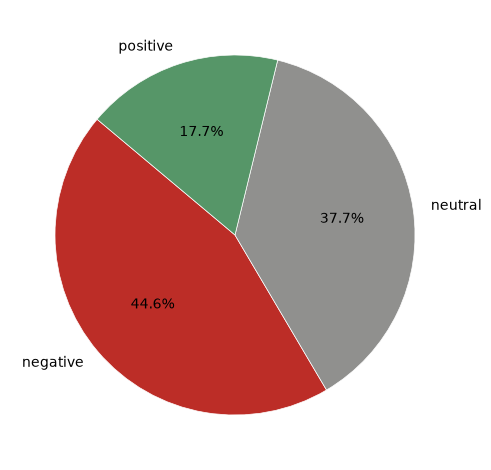

In [312]:
# Ensure the colors match the row order of  sentiment summary
colors = [color_map[roberta_label] for roberta_label in roberta_overall_sentiment_summary.index]

# Plot the pie chart
fig, ax = plt.subplots()
ax.pie(
    roberta_overall_sentiment_summary["percentage"],
    labels=roberta_overall_sentiment_summary.index,
    colors=colors,
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 0.5}
)

# Optimize layout and save the chart
plt.tight_layout()
# plt.show()
plt.savefig("roberta_shot_sentiment_pie_chart.svg", format='svg')

## But: target sentiment is the real issue

Even though transformer sentiment may answer if the text is positive or negative overall, our real question is if the text is positive or negative **towards Ferrari Luce**.

We need to add a targeted stance/sentiment layer: instead of only labels `positive / neutral / negative`, we need:
- positive_toward_luce
- negative_toward_luce
- mixed_or_unclear_toward_luce or irrelevant

This can be done with *zero-shot classification* first. **BART-large-MNLI** is commonly used for zero-shot classification by converting labels into hypotheses and using natural-language inference logic https://huggingface.co/facebook/bart-large-mnli

In [14]:
zero_shot_model = pipeline(
    task="zero-shot-classification",
    model="facebook/bart-large-mnli",
    truncation=True
)

config.json:   0%|          | 0.00/1.15k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [241]:
candidate_labels = [
    "enthusiasm about Ferrari Luce",
    "criticism of Ferrari Luce",
    "mixed feelings/ neutral discussion about Ferrari Luce"
]

hypothesis_template="This comment expresses {}."

In [242]:
def classify_luce_stance(text, candidate_labels=candidate_labels):

    result = zero_shot_model(text, candidate_labels=candidate_labels, multi_label=False, hypothesis_template=hypothesis_template)

    output = {
        "stance_label": result["labels"][0],
        "stance_score": result["scores"][0]
    }

    for label, score in zip(
        result["labels"],
        result["scores"]
    ):
        output[f"score_{label}"] = score

    return output

In [243]:
test_cases = [
    "Ferrari finally made an EV that looks amazing.",
    "Ferrari copied Tesla.",
    "The battery pack is 120 kWh.",
    "I like the styling but hate the screen.",
    "The new BMW M5 looks fantastic.",
    "The screen looks like Tesla.",
    "This costs too much.",
    "I saw one in Milan yesterday."
]

In [244]:
for text in test_cases:
    print(text, "\n", classify_luce_stance(text, candidate_labels), "\n")

Ferrari finally made an EV that looks amazing. 
 {'stance_label': 'enthusiasm about Ferrari Luce', 'stance_score': 0.9100918769836426, 'score_enthusiasm about Ferrari Luce': 0.9100918769836426, 'score_mixed feelings/ neutral discussion about Ferrari Luce': 0.07632064074277878, 'score_criticism of Ferrari Luce': 0.013587473891675472} 

Ferrari copied Tesla. 
 {'stance_label': 'criticism of Ferrari Luce', 'stance_score': 0.6939600110054016, 'score_criticism of Ferrari Luce': 0.6939600110054016, 'score_mixed feelings/ neutral discussion about Ferrari Luce': 0.24945539236068726, 'score_enthusiasm about Ferrari Luce': 0.05658454820513725} 

The battery pack is 120 kWh. 
 {'stance_label': 'mixed feelings/ neutral discussion about Ferrari Luce', 'stance_score': 0.5139280557632446, 'score_mixed feelings/ neutral discussion about Ferrari Luce': 0.5139280557632446, 'score_enthusiasm about Ferrari Luce': 0.29929319024086, 'score_criticism of Ferrari Luce': 0.18677867949008942} 

I like the stylin

In [245]:
# Apply on the whole data set
stance_results = (
    sentiment_df["translated_text"]
    .progress_apply(classify_luce_stance)
)

  0%|          | 0/11202 [00:00<?, ?it/s]

In [246]:
stance_df = pd.DataFrame(stance_results.tolist())

sentiment_df = pd.concat([sentiment_df, stance_df], axis=1)

In [247]:
sentiment_df.to_csv("ferrari_luce_reddit_sentiments_vader_roberta_zero_shot.csv", index=False)

In [308]:
# map zero-shot labels to positive", "negative" and "neutral"
label_map = {
    "enthusiasm about Ferrari Luce": "positive",
    "criticism of Ferrari Luce": "negative",
    "mixed feelings/ neutral discussion about Ferrari Luce": "neutral"
}

sentiment_df["zero_shot_label"] = (sentiment_df["stance_label"].map(label_map))

# count sentiment labels
zero_sentiment_counts = sentiment_df["zero_shot_label"].value_counts()

# convert counts to percentages
zero_sentiment_percentages = (
    sentiment_df["zero_shot_label"]
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
)

# combine counts and percentages into one table
zero_overall_sentiment_summary = pd.DataFrame({
    "count": zero_sentiment_counts,
    "percentage": zero_sentiment_percentages
})

zero_overall_sentiment_summary

,count,percentage
zero_shot_label,,
neutral,6631,59.2
negative,3620,32.3
positive,951,8.5


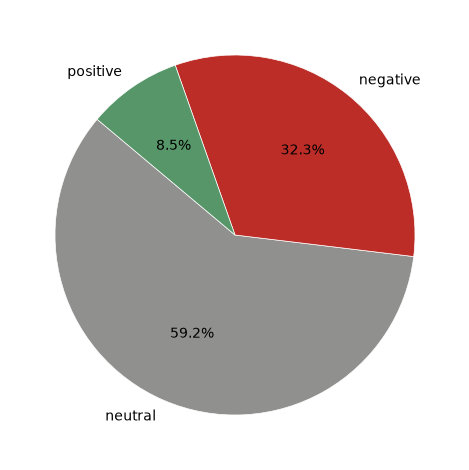

In [311]:
# Ensure the colors match the row order of  sentiment summary
colors = [color_map[zero_shot_label] for zero_shot_label in zero_overall_sentiment_summary.index]

# Plot the pie chart
fig, ax = plt.subplots()
ax.pie(
    zero_overall_sentiment_summary["percentage"],
    labels=zero_overall_sentiment_summary.index,
    colors=colors,
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 0.5}
)

plt.tight_layout()
plt.savefig("zero_shot_sentiment_pie_chart.svg", format='svg')

## Create a random sample evaluation data set and apply LLM on it

Add manually label for each record:
- positive
- negative
- mixed
- neutral (i.e. factual/ irrelevant/ ambiguous)

In [263]:
eval_df = sentiment_df.sample(
    200,
    random_state=42
)

In [264]:
eval_df.to_csv("ferrari_luce_reddit_sentiments_eval_df.csv", index=False)

In [265]:
# load back manually labeled data set
eval_df = pd.read_csv("ferrari_luce_reddit_sentiments_eval_df_manual_labels.csv")
# check manual label counts
eval_df["manual_label"].value_counts()

manual_label
neutral     94
negative    93
positive    13
Name: count, dtype: int64

In [266]:
eval_df.head(5)

,item_id,submission_id,item_type,subreddit,source_type,region_proxy,post_title,text,item_score,created_datetime,...,sentiment_label,roberta_label,roberta_score,stance_label,stance_score,score_criticism of Ferrari Luce,score_mixed feelings about Ferrari Luce,score_neutral discussion of Ferrari Luce,score_enthusiasm about Ferrari Luce,manual_label
0,opbwmvg,1tuotbu,comment,autoexpressuk,regional_auto,UK,Ferrari went high-tech but this new Rolls-Royc...,Does it come with a giant paper bag to cover i...,0,2026-06-02 15:02:29+00:00,...,negative,negative,0.931189,criticism of Ferrari Luce,0.642580,0.280836,0.642580,0.068223,0.008361,negative
1,opj58hz,1tvq9zq,comment,thegrandtour,other,Unclear / other,[Article] Former Top Gear Presenter James May ...,Here is a link to the post for those of you wh...,1,2026-06-03 15:26:56+00:00,...,positive,neutral,0.683139,mixed feelings/ neutral discussion about Ferra...,0.584449,0.217565,0.584449,0.095599,0.102386,neutral
2,op9rqxf,1ttr3v8,comment,autoexpressuk,regional_auto,UK,Here's the £36k Nissan Leaf and the £440k Ferr...,The plaid has great acceleration. So what? \nA...,1,2026-06-02 06:42:25+00:00,...,positive,neutral,0.527228,mixed feelings/ neutral discussion about Ferra...,0.315616,0.284817,0.315616,0.302219,0.097348,neutral
3,ooug5g9,1tqs84g,comment,Ferrari,core_auto,Global / brand-specific,Ferrari Luce Aerodynamics,Yeah nobody cares about this\n\nThis isn't a F...,1,2026-05-30 22:56:56+00:00,...,positive,negative,0.640513,mixed feelings/ neutral discussion about Ferra...,0.386148,0.316379,0.386148,0.290497,0.006976,negative
4,oo1pi16,1tojk7z,comment,formula1,motorsport_ferrari_context,Global / F1,Hamilton and Leclerc revealing the new Ferrari...,"Why? They failed spectacularly, nobody likes t...",10,2026-05-26 21:03:22+00:00,...,negative,negative,0.935585,criticism of Ferrari Luce,0.554747,0.280676,0.554747,0.154457,0.010120,negative


### Apply Gemini

In [ ]:
load_dotenv(override=True)
gemini_key = os.getenv("GEMINI_API_KEY")

In [251]:
# 1. Define the exact structure we want back from the API
class SentimentItem(BaseModel):
    row_id: int = Field(description="The unique ID passed in the request")
    sentiment: str = Field(description="Must be exactly 'positive', 'negative' or 'neutral'")
    confidence: float = Field(description="Confidence score between 0.0 and 1.0")

class BatchSentimentResponse(BaseModel):
    results: list[SentimentItem]

# Initialize the Gemini Client
client = genai.Client(api_key=gemini_key)

def process_sentiment_batch(dataframe, batch_size=50):
    """
    Processes a dataframe in cost-efficient chunks using Structured Outputs
    """
    all_results = []
    
    # We break the dataframe into chunks of 50 rows to maximize token efficiency
    for i in tqdm(range(0, len(dataframe), batch_size)):
        batch_df = dataframe.iloc[i:i+batch_size]
        
        # Format the data rows cleanly for the LLM input
        formatted_rows = []
        for idx, row in batch_df.iterrows():
            formatted_rows.append(f"ID: {idx} | Text: {row['text']}")
        
        prompt_content = "\n".join(formatted_rows)
        
        prompt = f"""
        You are an expert data science assistant specializing in brand monitoring.
        Analyze the sentiment of the following Reddit discussions toward 'Ferrari Luce'.
        
        Some comments may refer to the car indirectly using:
            - Ferrari
            - the new Ferrari EV
            - this car
            - this vehicle
            - comparisons with Tesla, Lucid, Lamborghini, Mercedes, etc.
            
            Classify the sentiment toward Ferrari Luce (the sentiments might be in different languages, not only English).
            
            Rules:
            - positive = favourable opinion toward Ferrari Luce
            - negative = criticism, mockery, sarcasm, ridicule toward Ferrari Luce
            - neutral = mixed fellings/ factual discussion without clear opinion (or irrelevant/ incomprehensible toward Ferrari Luce)
        
        For each item, classify it strictly as 'positive', 'negative' or 'neutral'.
        
        Items to analyze:
        {prompt_content}
        """
        
        try:
            # Using Gemini 2.5 Flash-Lite for ultra-low costs
            response = client.models.generate_content(
                model='gemini-2.5-flash-lite',
                contents=prompt,
                config=types.GenerateContentConfig(
                    response_mime_type="application/json",
                    response_schema=BatchSentimentResponse,
                    temperature=0.1, # Low temperature for consistent classification
                ),
            )
            
            # Parse the strict JSON structure returned
            batch_data = json.loads(response.text)
            all_results.extend(batch_data['results'])
            
        except Exception as e:
            print(f"\nError processing batch starting at row {i}: {e}")
            # Optional: Add a brief sleep if hitting Pay-As-You-Go rate limits
            time.sleep(2)
            
    # Convert results list to a DataFrame and map back
    results_df = pd.DataFrame(all_results)
    if not results_df.empty:
        results_df.set_index('row_id', inplace=True)
        return dataframe.join(results_df)
    return dataframe

In [267]:
# Run the Evaluation Set First
print("Running test evaluation on 200 rows...")
evaluated_test_df = process_sentiment_batch(eval_df, batch_size=50)

Running test evaluation on 200 rows...


  0%|          | 0/4 [00:00<?, ?it/s]

In [269]:
evaluated_test_df.to_csv("ferrari_luce_reddit_sentiments_eval_df_gemini.csv", index=False)

## Evaluate all method against manual labels

In [270]:
# rename each method's sentiment column for clarity (where needed)
evaluated_test_df = evaluated_test_df.rename(columns={
    "sentiment_label": "vader_label",
    "sentiment": "gemini_label"
})

# map zero-shot labels to positive", "negative" and "neutral"
label_map = {
    "enthusiasm about Ferrari Luce": "positive",
    "criticism of Ferrari Luce": "negative",
    "mixed feelings/ neutral discussion about Ferrari Luce": "neutral"
}

evaluated_test_df["zero_shot_label"] = (evaluated_test_df["stance_label"].map(label_map))

In [271]:
evaluated_test_df["zero_shot_label"].unique()

<ArrowStringArray>
['negative', 'neutral', 'positive']
Length: 3, dtype: str

In [273]:
# Check accuracy metrics for each method

print("VADER sentiments accuracy:")
print(classification_report(evaluated_test_df["manual_label"], evaluated_test_df["vader_label"]))

print("\nRoBERTa sentiments accuracy:")
print(classification_report(evaluated_test_df["manual_label"], evaluated_test_df["roberta_label"]))

print("\nZero-shot sentiments accuracy:")
print(classification_report(evaluated_test_df["manual_label"], evaluated_test_df["zero_shot_label"]))

print("\nGemini-2.5-flash-lite sentiments accuracy:")
print(classification_report(evaluated_test_df["manual_label"], evaluated_test_df["gemini_label"]))

VADER sentiments accuracy:
              precision    recall  f1-score   support

    negative       0.61      0.38      0.47        93
     neutral       0.71      0.23      0.35        94
    positive       0.10      0.85      0.18        13

    accuracy                           0.34       200
   macro avg       0.47      0.49      0.33       200
weighted avg       0.63      0.34      0.39       200


RoBERTa sentiments accuracy:
              precision    recall  f1-score   support

    negative       0.70      0.67      0.68        93
     neutral       0.68      0.55      0.61        94
    positive       0.31      0.85      0.46        13

    accuracy                           0.62       200
   macro avg       0.57      0.69      0.58       200
weighted avg       0.67      0.62      0.63       200


Zero-shot sentiments accuracy:
              precision    recall  f1-score   support

    negative       0.59      0.40      0.47        93
     neutral       0.50      0.66      0

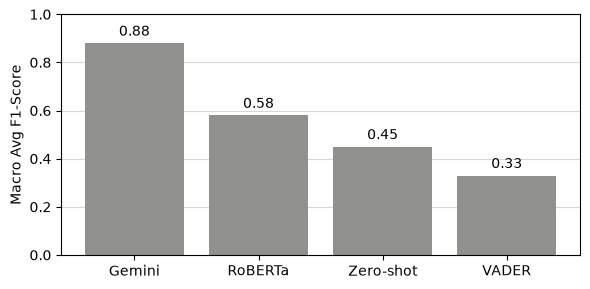

In [316]:
# Data sorted from highest to lowest
models = ['Gemini', 'RoBERTa', 'Zero-shot', 'VADER']
f1_scores = [0.88, 0.58, 0.45, 0.33]
bar_color = '#90908E'  # Consistent grey color

# Create bar plot using subplots
fig, ax = plt.subplots(figsize=(6, 3))
bars = ax.bar(models, f1_scores, color=bar_color, width=0.8)

# Axis labels and styling
ax.set_ylabel('Macro Avg F1-Score')
# ax.set_title('Macro Avg F1-Scores by Model')
ax.set_ylim(0, 1.0)  # Sets y-axis range appropriately for F1-scores

# Add horizontal grid behind the bars
ax.set_axisbelow(True)  # Ensures the grid lines are drawn behind the bars
ax.grid(axis='y', alpha=0.5)

# Add score labels on top of each bar
for bar in bars:
    height = bar.get_height()
    ax.annotate(
        f'{height:.2f}',
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 3),  # 3 points vertical offset
        textcoords="offset points",
        ha='center', 
        va='bottom'
    )

# Optimize layout and save the chart in editable vector format (SVG)
plt.tight_layout()
plt.savefig('f1_scores_bar_chart.svg', format='svg')

### Run Gemini on the Full Dataset

In [274]:
print("Starting production run on full dataset...")
start_time = time.time()

final_classified_df = process_sentiment_batch(sentiment_df, batch_size=50)

final_classified_df.to_csv("ferrari_luce_reddit_sentiments_final.csv", index=True)

print(f"Done! Completed in {round((time.time() - start_time)/60, 2)} minutes.")

Starting production run on full dataset...


  0%|          | 0/225 [00:00<?, ?it/s]

Done! Completed in 16.68 minutes.


### Overall Gemini sentiment summary

In [276]:
# count sentiment labels
sentiment_counts_gemini = final_classified_df["sentiment"].value_counts()

# convert counts to percentages
sentiment_percentages_gemini = (
    final_classified_df["sentiment"]
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
)

# combine counts and percentages into one table
gemini_overall_sentiment_summary = pd.DataFrame({
    "count": sentiment_counts_gemini,
    "percentage": sentiment_percentages_gemini
})

gemini_overall_sentiment_summary

,count,percentage
sentiment,,
negative,5474,48.9
neutral,5022,44.8
positive,702,6.3


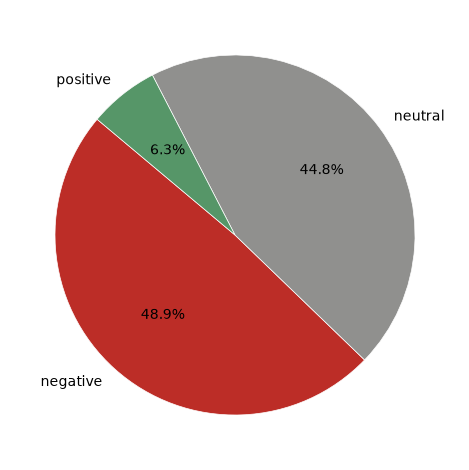

In [304]:
# Ensure the colors match the row order of  sentiment summary
colors = [color_map[sentiment] for sentiment in gemini_overall_sentiment_summary.index]

# Plot the pie chart
fig, ax = plt.subplots()
ax.pie(
    gemini_overall_sentiment_summary["percentage"],
    labels=gemini_overall_sentiment_summary.index,
    colors=colors,
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 0.5}
)

# Optimize layout and save the chart
plt.tight_layout()
# plt.show()
plt.savefig("gemini_sentiment_pie_chart.svg", format='svg')

### Sentiment by subreddit

In [277]:
# create sentiment count table by subreddit
sentiment_by_subreddit_counts = pd.crosstab(
    final_classified_df["subreddit"],
    final_classified_df["sentiment"]
)

# convert counts to row percentages
sentiment_by_subreddit_pct = (
    sentiment_by_subreddit_counts
    .div(sentiment_by_subreddit_counts.sum(axis=1), axis=0)
    .mul(100)
    .round(1)
)

# add total comment count for context
sentiment_by_subreddit_pct["record_count"] = sentiment_by_subreddit_counts.sum(axis=1)

# show only subreddits with enough comments for meaningful comparison
sentiment_by_subreddit_pct = sentiment_by_subreddit_pct[
    sentiment_by_subreddit_pct["record_count"] >= 50
].sort_values("record_count", ascending=False)

sentiment_by_subreddit_pct.head(30)

sentiment,negative,neutral,positive,record_count
subreddit,,,,
Ferrari,55.0,38.6,6.4,3200
ItalyMotori,40.9,53.2,5.8,618
supercars,34.7,54.1,11.2,580
spotted,70.4,24.8,4.8,500
autoexpressuk,49.0,43.0,7.9,467
cars,28.5,64.3,7.2,442
formula1,53.1,46.1,0.8,384
carros,57.1,40.1,2.9,312
electriccars,48.3,43.3,8.3,300


### Sentiment by source type (i.e. post/ comment)

In [278]:
source_type_sentiment_counts = pd.crosstab(
    final_classified_df["item_type"],
    final_classified_df["sentiment"]
)

source_type_sentiment_pct = (
    source_type_sentiment_counts
    .div(source_type_sentiment_counts.sum(axis=1), axis=0)
    .mul(100)
    .round(1)
)

source_type_sentiment_pct["record_count"] = source_type_sentiment_counts.sum(axis=1)

source_type_sentiment_pct.sort_values("record_count", ascending=False)

sentiment,negative,neutral,positive,record_count
item_type,,,,
comment,49.0,44.8,6.2,10956
post,44.2,47.5,8.3,242


### Sentiment by regional proxy

In [324]:
# update regional proxy
region_map = {
    # UK
    "CarTalkUK": "UK",
    "ElectricVehiclesUK": "UK",
    "ukcarwow": "UK",
    "autoexpressuk": "UK",
    "pistonheads": "UK",
    "TheIntercooler": "UK",

    #USA
    "sanfrancirclejerk": "USA",
    "bayarea": "USA",
    "sanfrancisco": "USA",
    "dougdemuro": "USA",
    "JasonCammisa": "USA",
    "regularcarreviews": "USA",

    # Italy
    "ItalyMotori": "Italy",
    "Motorionline": "Italy",
    "Formula1Italia": "Italy",
    "Economia_Italiana": "Italy",
    "ItaliaBox": "Italy",
    "TeenagersITA": "Italy",
    "VeniceContemporaryArt": "Italy",
    "LinkedInCringeIT": "Italy",
    "domandaonesta": "Italy",

    # Germany / German-language
    "automobil": "Germany / German-language",
    "CarwowDE": "Germany / German-language",
    "SmartDroidDE": "Germany / German-language",
    "wasletztepreis": "Germany / German-language",
    "Weltnachrichten": "Germany / German-language",
    "Unbeliebtemeinung": "Germany / German-language",
    "SirApfelot": "Germany / German-language",
    "resilienzDE": "Germany / German-language",

    # India
    "CarsIndia": "India",
    "Autoexpoindia": "India",
    "cargeeksindia": "India",
    "indocartalk": "India",
    "Hotwheelsindia": "India",
    "BusinessTodayNews": "India",
    "TeensofKerala": "India",

    # South Africa
    "CarTalkZA": "South Africa",

    # UAE / Dubai
    "DubaiPetrolHeads": "UAE / Dubai",

    # Hungary
    "CartalkHungary": "Hungary",

    # Brazil / Portugal / Portuguese-language
    "carros": "Brazil / Portuguese-language",
    "Carroseletricos": "Brazil / Portuguese-language",
    "CarrosEletricosPT": "Portugal / Portuguese-language",
    "reclamacoesfuteis": "Portuguese-language",

    # Australia / New Zealand
    "CarsAustralia": "Australia",
    "EVAustralia": "Australia",
    "KiwiEV": "New Zealand",

    # Philippines / Malaysia / Pakistan
    "Gulong": "Philippines",
    "CarsPH": "Philippines",
    "phcars": "Philippines",
    "Tech_Philippines": "Philippines",
    "kereta": "Malaysia",
    "Bolehland": "Malaysia",
    "PakistanAutoHub": "Pakistan",

    # France / French-language
    "Vilebrequin": "France / French-language",
    "Frandroid": "France / French-language",
    "opinionnonpopulaire": "France / French-language",
    "rienabranler": "France / French-language",

    # Other regional contexts
    "srbija_automobili": "Serbia",
    "Roumanie": "Romania",
    "CarCulture_ES": "Spain / Spanish-language",
    "CarwowES": "Spain / Spanish-language",
    "Kenya_got_rides": "Kenya",
    "ottawa": "Canada / Ottawa",
    "HotWheelsTr": "Turkey",
    "siimkuusik": "Estonia",
    "Sino": "China",
    "unket": "Sweden",

    # global or non-country-specific
    "Ferrari": "Global / brand-specific",
    "cars": "Global",
    "supercars": "Global",
    "electricvehicles": "Global",
    "electriccars": "Global",
    "CarDesign": "Global",
    "Design": "Global",
    "IndustrialDesign": "Global",
    "formula1": "Global / F1",
    "LUCID": "Global / brand-specific",
    "Toyota": "Global / brand-specific",
    "Audi": "Global / brand-specific",
    "Porsche": "Global / brand-specific",
    "lamborghini": "Global / brand-specific",
    "BMWi3": "Global / brand-specific"
}

final_classified_df["region_proxy"] = final_classified_df["subreddit"].map(region_map).fillna("Global")

In [325]:
region_sentiment_counts = pd.crosstab(
    final_classified_df["region_proxy"],
    final_classified_df["sentiment"]
)

region_sentiment_pct = (
    region_sentiment_counts
    .div(region_sentiment_counts.sum(axis=1), axis=0)
    .mul(100)
    .round(1)
)

region_sentiment_pct["record_count"] = region_sentiment_counts.sum(axis=1)

region_sentiment_pct = region_sentiment_pct[
    region_sentiment_pct["record_count"] >= 50
].sort_values("record_count", ascending=False)

region_sentiment_pct

sentiment,negative,neutral,positive,record_count
region_proxy,,,,
Global,45.8,46.7,7.5,3876
Global / brand-specific,53.9,39.8,6.3,3535
UK,47.8,44.8,7.4,1018
Italy,40.0,55.1,4.9,732
Global / F1,53.1,46.1,0.8,384
USA,52.9,43.7,3.4,348
Brazil / Portuguese-language,57.1,40.1,2.9,312
Germany / German-language,44.6,53.2,2.2,186
Hungary,21.0,76.0,3.0,167


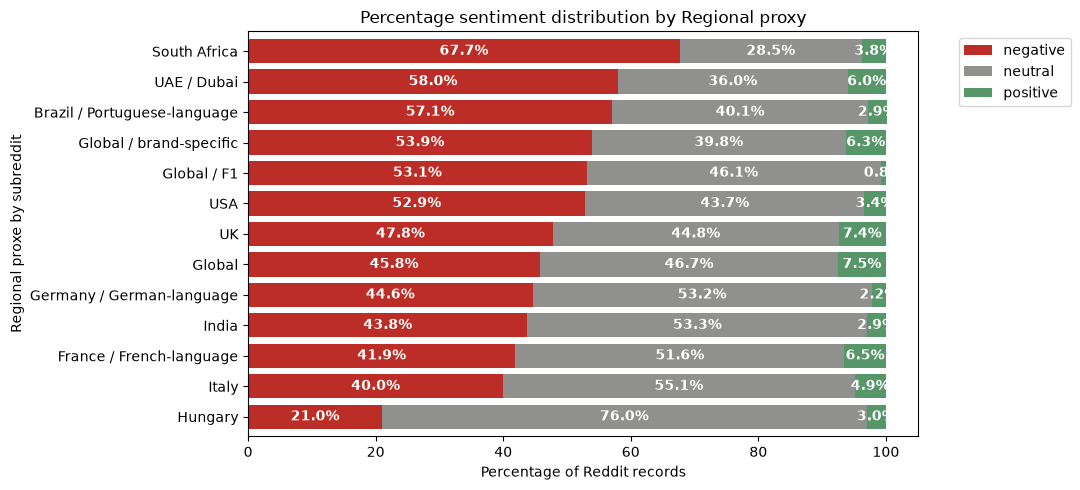

In [328]:
# define the sentiment label order
sentiment_order = ["negative", "neutral", "positive"]

# 1. Sort the DataFrame by "negative" percentage in descending order
region_sentiment_pct_sorted = region_sentiment_pct.sort_values(by="negative", ascending=False)

# select only the sentiment percentage columns for plotting
query_plot_values = region_sentiment_pct_sorted[sentiment_order]

# 2. Create a horizontal stacked bar chart using subplots
fig, ax = plt.subplots(figsize=(11, 5))
query_plot_values.plot(
    kind="barh", 
    stacked=True, 
    color=[color_map[label] for label in sentiment_order], 
    ax=ax,
    width=0.8
)

# create a horizontal stacked bar chart
ax.invert_yaxis()
# ax = query_plot_values.plot(kind="barh", stacked=True, figsize=(11, 7), color=[color_map[label] for label in sentiment_order])
ax.set_title("Percentage sentiment distribution by Regional proxy")
ax.set_xlabel("Percentage of Reddit records")
ax.set_ylabel("Regional proxe by subreddit")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

# 3. Add percentage labels inside the bars
for container in ax.containers:
    # Generate labels only for segments greater than 0% to prevent overlapping/clutter
    labels = [f'{v.get_width():.1f}%' if v.get_width() > 0 else '' for v in container]
    
    ax.bar_label(
        container, 
        labels=labels, 
        label_type='center', 
        color='white', 
        fontweight='bold'
    )

# 4. Optimize layout and save to editable SVG format
plt.tight_layout()
plt.savefig("sentiment_distribution_by_regional_proxy.svg", format='svg')

plt.show()